# F-Praktikum: Quantum Computer Simulation

**Author:** Ayush Singh, Shanidhaya Shashwat 
**Project Goal:** To build a modular, N-qubit quantum circuit simulator from scratch using Python and QuTiP, culminating in the generation and physical analysis of random mixed states based on the Życzkowski et al. paper (arXiv:1010.3570).

## Project Overview
This notebook serves as an interactive interface to the quantum engine developed during this Praktikum. The project is divided into three core physics milestones:
1. **The Circuit Engine:** Parsing and applying continuous parameterized standard and controlled quantum gates to arbitrary $N$-qubit systems.
2. **Measurement Mechanics:** Simulating quantum superposition collapse via projective measurements.
3. **Random State Generation:** Generating and analyzing the geometry of Haar, Hilbert-Schmidt, and Bures random density matrices on the Bloch Sphere.

In [1]:
# --- Setup and Imports ---
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Ensure plots render directly inside the notebook
%matplotlib inline

# Import our custom modules
from circuit_engine import apply_instruction, measure_qubit
from generator import generate_random_circuit
from visualize import draw_ascii_circuit
from random_states import haar_random_state, hilbert_schmidt_random_state, bures_random_state
from plot_distributions import plot_random_distributions
from plot_purity import plot_purity_distributions
from benchmark_random_states import run_benchmark

print("Quantum Engine initialized and ready!")

Quantum Engine initialized and ready!


## Part 1: Circuit Generation & Visualization
Our engine is capable of automatically generating deeply randomized circuits to scramble quantum information. It selects randomly between single-qubit rotations ($R_x, R_y, R_z$) and multi-qubit entangling gates ($CNOT$, $C-H$, $ISWAP$, etc.).

In [2]:
NUM_QUBITS = 3
NUM_LAYERS = 5

print(f"Generating {NUM_QUBITS}-qubit random circuit with {NUM_LAYERS} layers...")
ops, descs, instrs = generate_random_circuit(NUM_QUBITS, NUM_LAYERS)

# Draw the resulting circuit using our ASCII visualizer
draw_ascii_circuit(NUM_QUBITS, instrs)

Generating 3-qubit random circuit with 5 layers...

=== Generated Quantum Circuit ===
q0: ────[Y]──────[Y]───────────────[T]──────[X]────
q1: ───[Rz]──────[T]───────■───────[X]───────│─────
q2: ────[X]──────[X]──────[Y]──────[X]───────■─────



## Part 2: Wavefunction Evolution & Measurement
We can apply the generated circuit to a baseline $|00...0\rangle$ state. Following standard quantum mechanics, applying projective measurement $P_m$ to a specific qubit collapses the system into a definite state with probability $p = \text{Tr}(P_m \rho)$.

In [3]:
# 1. Initialize |000>
state = qt.tensor([qt.basis(2, 0)] * NUM_QUBITS)

# 2. Evolve the state through the random circuit
for op in ops:
    state = op * state
    
print("State evolved successfully.")
print(f"Final State Purity before measurement: {(state * state.dag()).tr().real:.4f}")

# 3. Measure Qubit 0
target_q = 0
print(f"\n--- Measuring Qubit {target_q} ---")
result, collapsed_state = measure_qubit(state, target_q)

print(f"Classical Result: {result}")
print("System successfully collapsed to reflect the measurement!")

State evolved successfully.
Final State Purity before measurement: 1.0000

--- Measuring Qubit 0 ---
Classical Result: 1
System successfully collapsed to reflect the measurement!


## Part 3: Random Density Matrices (arXiv:1010.3570)
To simulate open quantum systems interacting with an environment, we generate random mixed states using complex Ginibre matrices ($G$). According to the literature, we can generate three distinct ensembles:

1. **Haar States:** Pure states generated by uniform unitaries. $\rho = |\psi\rangle\langle\psi|$
2. **Hilbert-Schmidt (HS) States:** Created by mathematically tracing out an environment of equal dimension. $\rho \propto G G^\dagger$
3. **Bures States:** A mixed ensemble generated via rejection-sampled unitaries, biasing the states toward the pure boundary. $\rho \propto (I+U)GG^\dagger(I+U^\dagger)$

In [4]:
# Generate one of each state to verify QuTiP matrix properties
rho_haar = haar_random_state(2)
rho_hs = hilbert_schmidt_random_state(2)
rho_bures = bures_random_state(2)

print("Haar Purity (Expected 1.0):", (rho_haar**2).tr().real)
print("HS Purity (Expected ~0.80):", (rho_hs**2).tr().real)
print("Bures Purity (Expected ~0.87):", (rho_bures**2).tr().real)

Haar Purity (Expected 1.0): 0.9999999999999996
HS Purity (Expected ~0.80): 0.8244225161701231
Bures Purity (Expected ~0.87): 0.6779290528184214


### 3.1 Visualizing Geometries on the Bloch Sphere
Because random matrices are hard to interpret numerically, we map hundreds of samples to the $X, Y, Z$ coordinates of the Bloch Sphere using the Pauli expectation values: $x = \text{Tr}(\sigma_x \rho)$.

*Note: This will pop open a matplotlib window to render the 3D graphics.*

Generating 500 states for each distribution. Please wait...
Rendering complete!


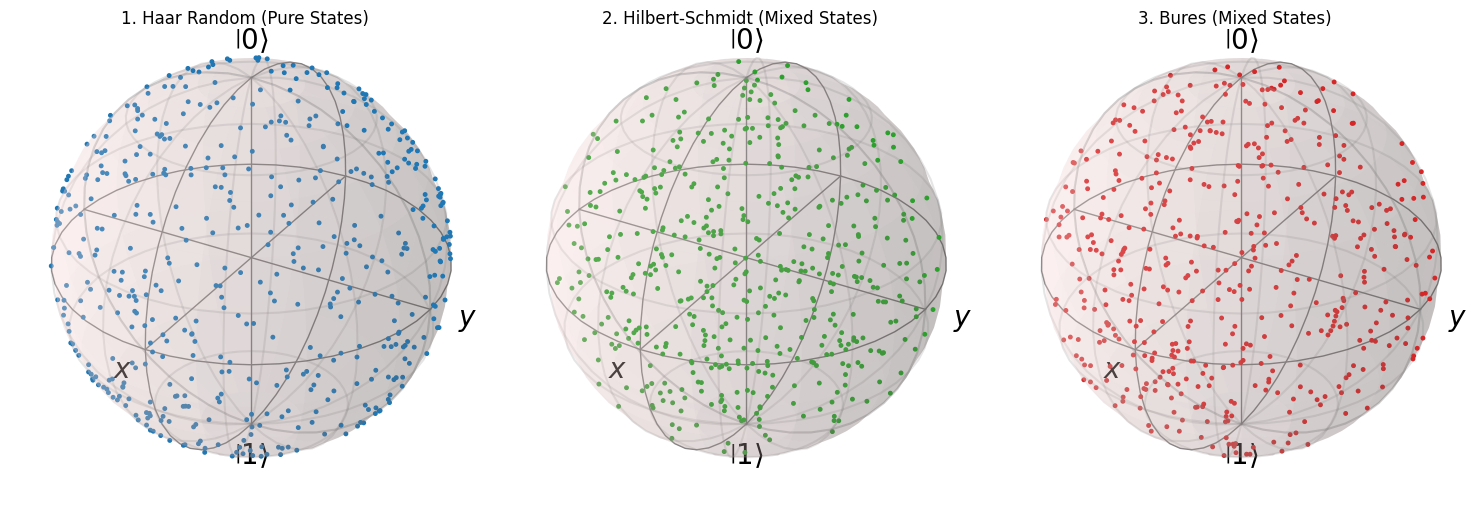

In [5]:
# Renders 500 points for each distribution on 3 side-by-side Bloch spheres
plot_random_distributions(num_samples=500)

### 3.2 Purity Histograms
To rigorously prove the visual geometries above, we calculate the purity $\text{Tr}(\rho^2)$ of 10,000 generated states and plot their probability densities.
- **Haar** must spike at $1.0$.
- **HS** must uniformly fill the volume down to $0.5$.
- **Bures** must heavily bias towards the $1.0$ surface.

Generating 10000 states for each distribution. This may take a moment...
Done! Displaying plot...


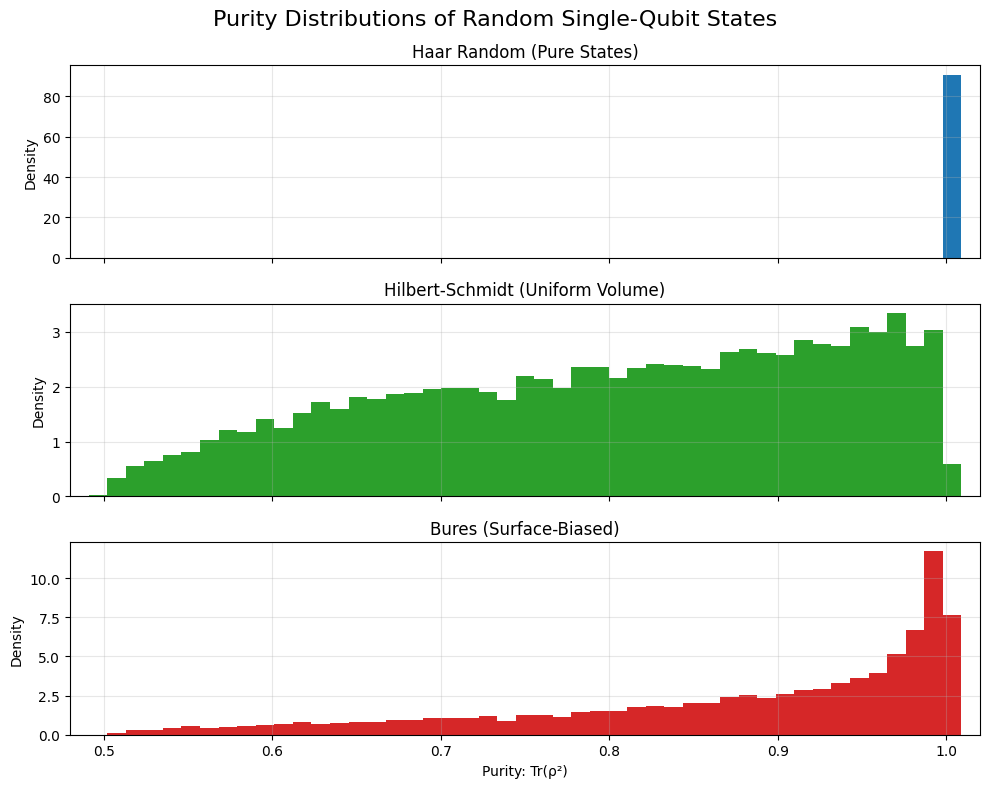

In [6]:
# Generates 10,000 states and plots the mathematical purity distributions
plot_purity_distributions(num_samples=10000)

##  Part 4: Physical vs. Mathematical Benchmarking
Why do we use the mathematical Ginibre matrix equations above instead of just physically simulating a random circuit and tracing out an environment every time? 
The benchmark below proves the exponential performance cost of simulating the environment physically.

System Qubits   | Circuit Time (s)     | Math Time (s)  
-------------------------------------------------------
1               | 0.0543               | 0.000304       
2               | 0.0939               | 0.000345       
3               | 0.1624               | 0.000308       
4               | 0.4969               | 0.000469       

Benchmark complete! Rendering plot...


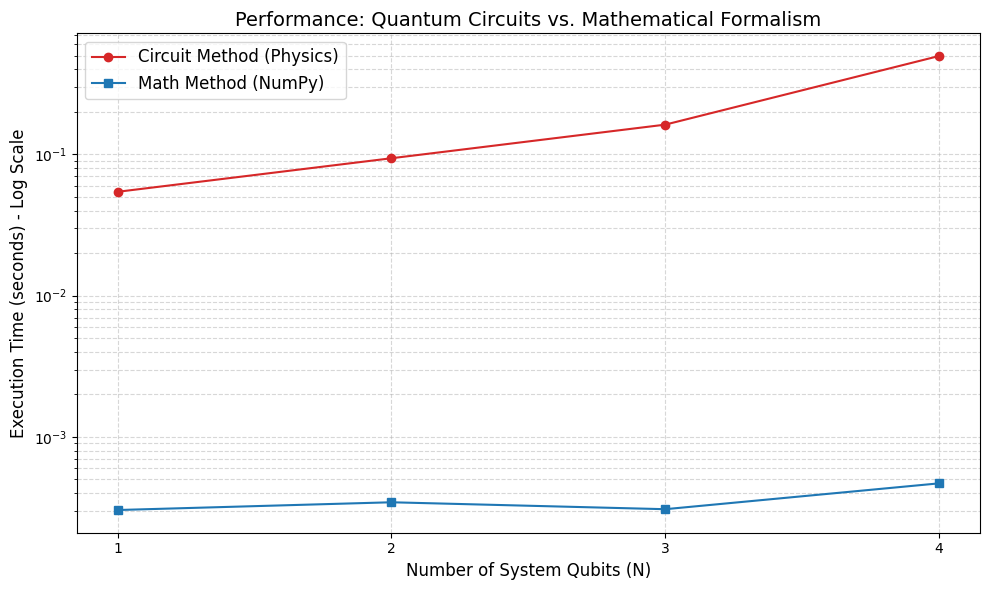

In [7]:
# Runs the benchmark comparing Circuit Evolution vs. NumPy Matrix generation
run_benchmark()